---
### population vs sample

population is the entire group we care about, sample is the small part we
actually collect data from

we cant study the whole population most of the time cause its huge, takes too
long and costs too much

so we take a sample and use it to guess something about the population - thats
literally why its called inferential stats, we infer stuff about population from
the sample


---
### point estimate and margin of error

if we say population mean = sample mean thats called a point estimate, just one
number as our guess

problem is its rarely exact, sample mean of 85 doesnt mean population mean is
exactly 85, could be a bit off either side

so instead of one number we give a range - margin of error is basically the
cushion we add/subtract around our estimate

margin of error = z * (s / sqrt(n))


---
### confidence interval

CI = sample mean +/- margin of error

= x_bar +/- z * (s/sqrt(n))

things to remember
- we never get the exact population mean, only a range it probably lies in
- bigger interval = more confidence, smaller interval = less confidence
- 100% confidence would need such a wide range its useless, so we stick to 90/95/99%
- sample mean stays same, only the margin of error changes with confidence level


---
### normal distribution and z score

normal dist is the bell curve, mean = median = mode, symmetric on both sides

z score tells how many standard deviations a value is away from mean

z table values i keep forgetting so noting here
90% -> z = 1.645
95% -> z = 1.96
99% -> z = 2.576


In [1]:
from scipy import stats

for cl in [0.90, 0.95, 0.99]:
    z = stats.norm.ppf(1 - (1-cl)/2)
    print(cl, "->", round(z,3))


0.9 -> 1.645
0.95 -> 1.96
0.99 -> 2.576


---
### confidence interval example

retail company wants avg spending per customer during holiday sale
sample of 50 customers, mean spending 85 dollars, sample std dev 15
find 95% CI for true population mean


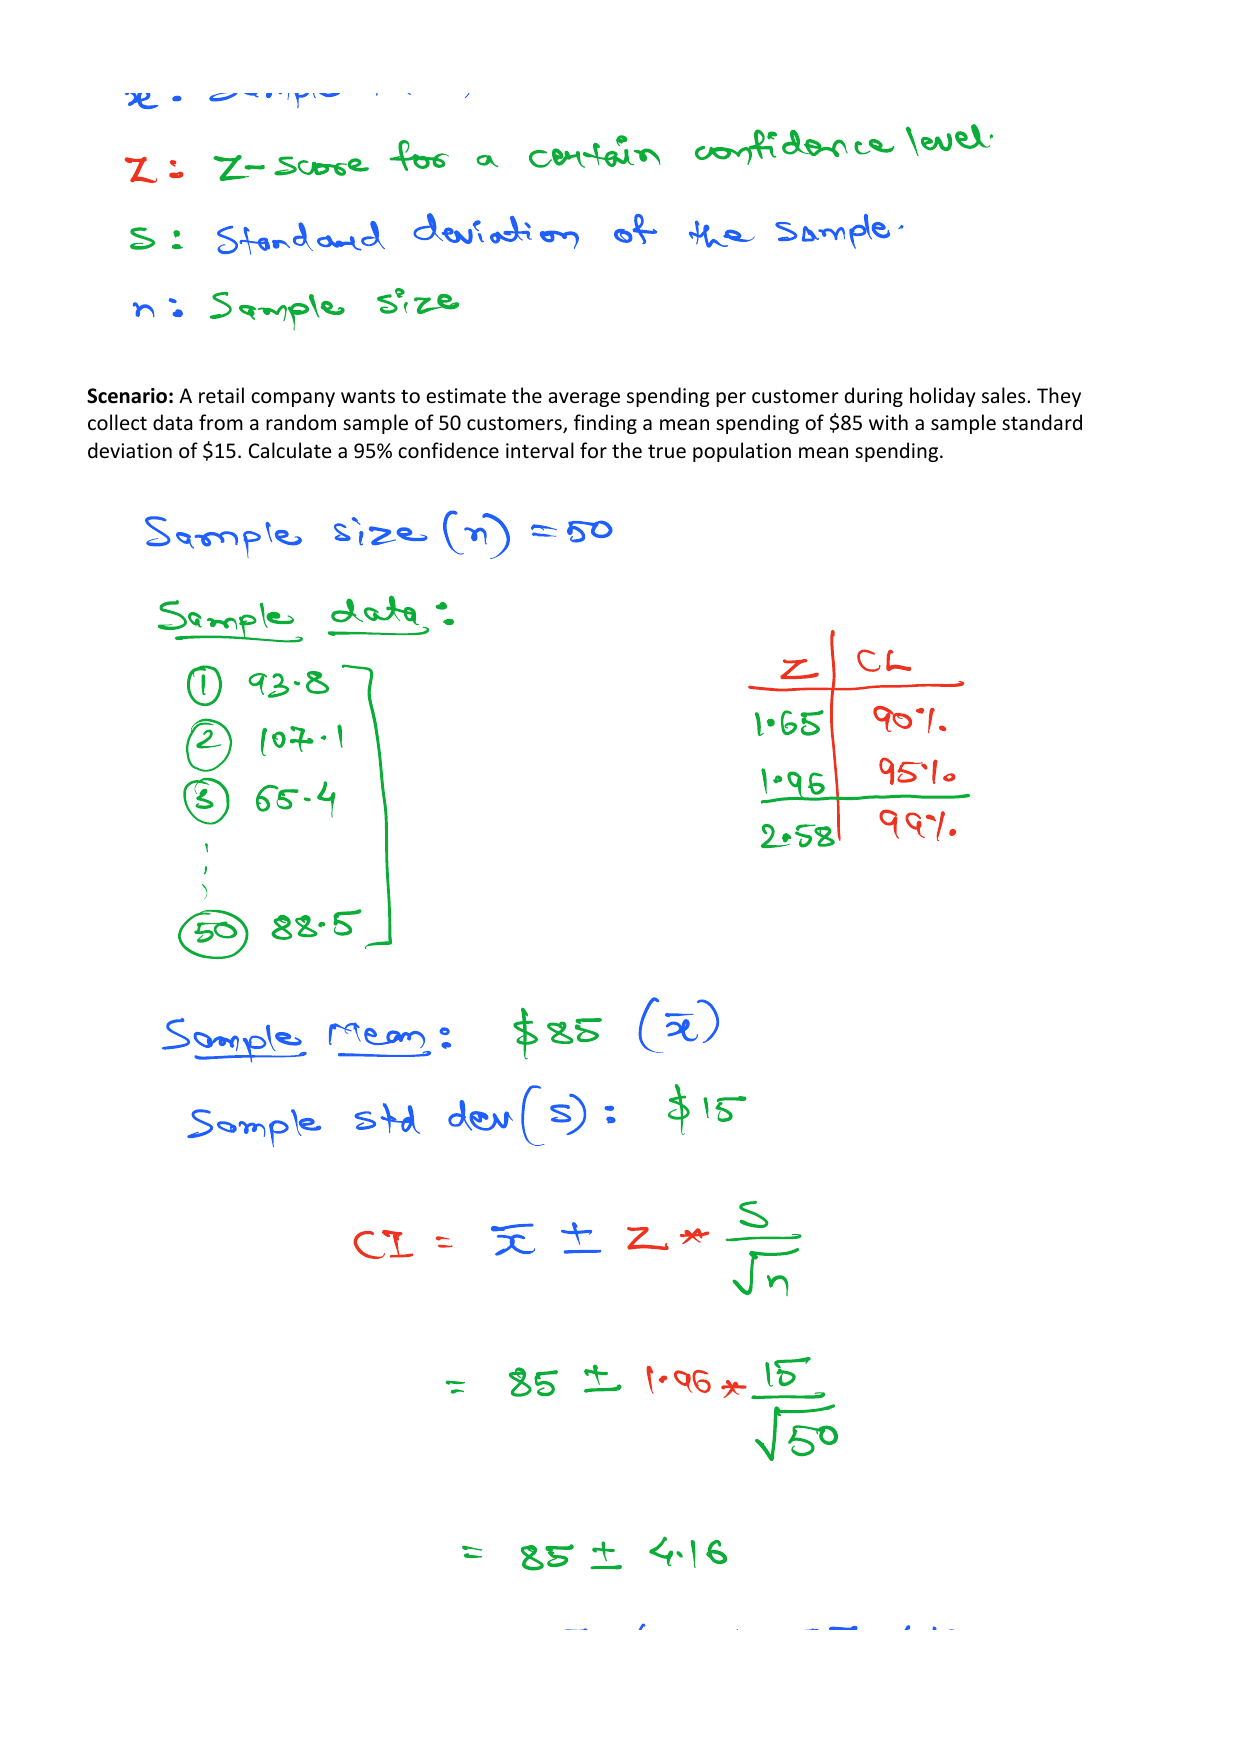

In [2]:
import math
from scipy import stats

n = 50
x_bar = 85
s = 15
confidence = 0.95

z = stats.norm.ppf(1 - (1-confidence)/2)
se = s / math.sqrt(n)
moe = z * se

lower = x_bar - moe
upper = x_bar + moe

print("z:", round(z,3))
print("standard error:", round(se,4))
print("margin of error:", round(moe,4))
print("95% CI:", (round(lower,2), round(upper,2)))


z: 1.96
standard error: 2.1213
margin of error: 4.1577
95% CI: (np.float64(80.84), np.float64(89.16))


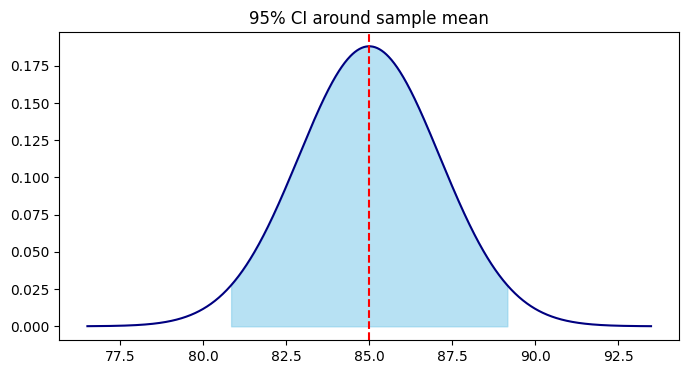

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(x_bar - 4*se, x_bar + 4*se, 1000)
y = stats.norm.pdf(x, loc=x_bar, scale=se)

plt.figure(figsize=(8,4))
plt.plot(x,y,color="navy")
ci_x = np.linspace(lower, upper, 300)
plt.fill_between(ci_x, stats.norm.pdf(ci_x, loc=x_bar, scale=se), color="skyblue", alpha=0.6)
plt.axvline(x_bar, color="red", linestyle="--")
plt.title("95% CI around sample mean")
plt.show()


so we can say we are 95% confident true avg spending of all customers lies
between the lower and upper bound we got, not that 95% of customers spend that much


---
### how big should sample be

after some research the answer is central limit theorem

CLT - if sample size is more than 30 from any population, the kde plot of that
sample will always be normally distributed

doesnt matter how weird the population is, after 30 values sample becomes normal
dist, bigger sample is still better but 30 is the bare minimum


---
### sampling methods

random sampling - just pick random samples, works fine when population is kind
of uniform, like researching a 20rs lays packet, doesnt matter which one you pick

but say we want avg income of indian families, population is 5 lakh families,
cant do random sampling here cause there are way more middle class than rich so
mean will shift

so instead we split population into groups - rich middle and poor - and sample
from each group according to their actual proportion in population (10% rich,
50% middle, 40% poor, not equal 33% each)


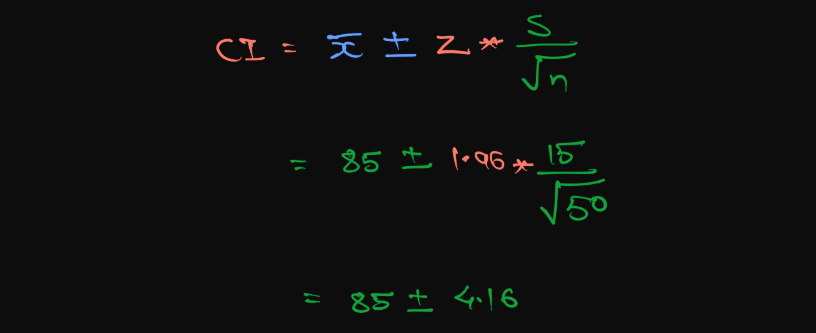

this is called stratified sampling, one sample gets made from all groups
combined and mean of that is used


---
### hypothesis testing

basically we assume something (null hypothesis) and then check if the data gives
us enough evidence to reject that assumption

business usecase - critical cases like 99%/95%(significance - 1%/5%)

hypothesis testing - in confidence interval, we know the population value and find
sample, here we will learn something about population by sample

null hypothesis -> pm = sm
alternative hypothesis -> pm != sm

objective - try to reject null hypothesis, when we can reject null hypothesis we
have strong evidence against null

how do we get p value - we run the hypothesis test on the sample data, p value is
basically the evidence

if p value is small (less than significance) - evidence is strong enough to
reject null, if p value is big - not enough evidence, fail to reject null

steps for checking
1. write null and alternative
   null hypothesis -> it is an assumption that pm = sm
2. sign -> =, !=, <, >
3. how do we get p value -> sample data -> hypothesis test


---
### one sample z test

used when - one sample, numerical data, population std dev known, both sample
and population mean known


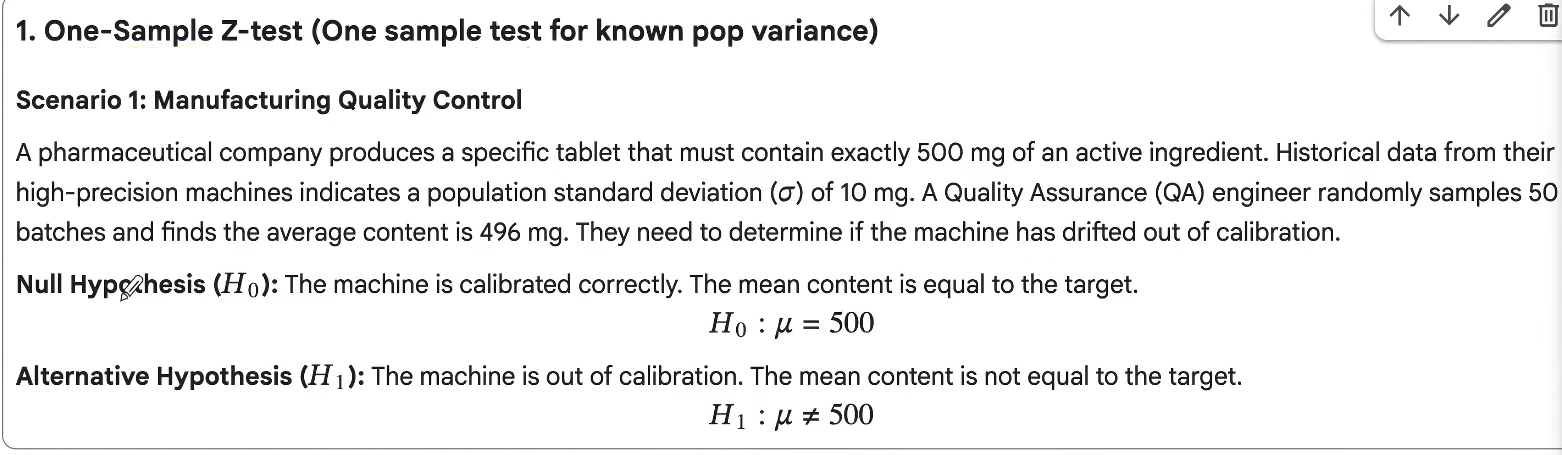

population mean = 500mg, population std = 10mg, sample mean = 496mg, sample
size = 50, is the machine working fine or not


In [4]:
import numpy as np
from scipy import stats

pop_mean = 500
pop_std = 10
sample_mean = 496
sample_size = 50

z_stat = (sample_mean - pop_mean) / (pop_std / np.sqrt(sample_size))
p_value = stats.norm.sf(abs(z_stat))

print("z stat:", round(z_stat,4))
print("p value:", round(p_value,4))

if p_value < 0.01:
    print("reject null hypothesis")
else:
    print("failed to reject null")


z stat: -2.8284
p value: 0.0023
reject null hypothesis


z stat tells how far our sample mean is from population mean in terms of std
dev, here its about 2.8 std dev away which is pretty far, so sample mean falls
outside the 95%/99% range and we drop the null hypothesis


---
### one sample t test

population mean is 330, population std dev not given so no z test, we go with
t test instead


In [5]:
import numpy as np
from scipy.stats import ttest_1samp, shapiro

sample_data = np.array([332,329,331,328,334,330,327,333,329,331,332,328,330,334,329])

shapiro_stat, shapiro_p = shapiro(sample_data)
print("shapiro p value:", shapiro_p)  # if > 0.05 data is normally distributed

t_stat, p_value = ttest_1samp(sample_data, popmean=330)
print("t stat:", t_stat)
print("p value:", p_value)


shapiro p value: 0.5372052570493318
t stat: 0.8217036268592368
p value: 0.4250186718429416


---
### two sample t test

now instead of comparing sample to population, comparing two samples to each other

before running it, two assumptions to check
- both samples should be normally distributed
- both samples should have similar variance (for the standard version of test)


In [6]:
import numpy as np
from scipy.stats import shapiro, levene, ttest_ind

dept_a = np.array([4500, 4700, 4200, 4800, 4600, 4400, 4550, 4650, 4750, 4300])
dept_b = np.array([4000, 4150, 4100, 3950, 4200, 4050, 4100, 4000, 4150, 4050])

# normality check
print("shapiro a:", shapiro(dept_a).pvalue)
print("shapiro b:", shapiro(dept_b).pvalue)
# both > 0.05 so both normally distributed

# variance check
lev_stat, lev_p = levene(dept_a, dept_b)
print("levene p:", lev_p)


shapiro a: 0.7713665744080458
shapiro b: 0.8485975564649946
levene p: 0.029281204462727434


In [7]:
# variance came out different (levene p < 0.05) so equal_var=False
t_stat, p_value = ttest_ind(dept_a, dept_b, equal_var=False)
print("t stat:", t_stat)
print("p value:", p_value)
# p value less than 0.05 so we reject null, salaries of dept a and b are not same


t stat: 7.019357197399489
p value: 1.4988271248674497e-05


battery example - 12 batteries from two suppliers, small sample so t test
again


In [8]:
supplier_a = [24.1, 23.8, 24.5, 23.0, 24.2, 23.9, 24.0, 23.5, 24.8, 24.1, 23.7, 24.3]
supplier_b = [22.8, 23.1, 22.5, 23.0, 22.9, 23.5, 22.1, 23.3, 22.8, 23.0, 22.7, 23.4]

print("mean a:", np.mean(supplier_a))
print("mean b:", np.mean(supplier_b))

lev_stat2, lev_p2 = levene(supplier_a, supplier_b)
print("levene p:", lev_p2)  # > 0.05 so same variance this time

print("shapiro a:", shapiro(supplier_a).pvalue)
print("shapiro b:", shapiro(supplier_b).pvalue)
# both normal, both same variance, so equal_var=True

t2_stat, t2_p = ttest_ind(supplier_a, supplier_b, equal_var=True)
print("t stat:", t2_stat)
print("p value:", t2_p)
# less than 0.05 so drop null, going with battery supplier a


mean a: 23.99166666666667
mean b: 22.925
levene p: 0.6672974677115981
shapiro a: 0.9875073378105873
shapiro b: 0.878782891448451
t stat: 6.043753454334629
p value: 4.401143857233154e-06


---
### anova

used when we have more than two samples and data is numerical, samples should be
independent from each other


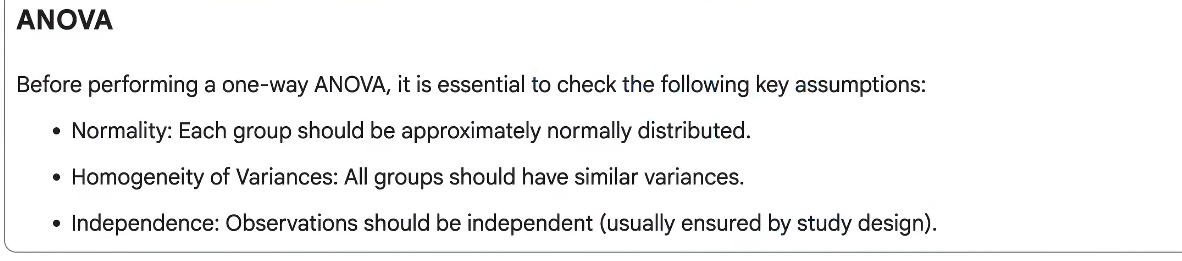

In [9]:
import numpy as np
from scipy.stats import f_oneway, shapiro, levene

center_1 = np.array([8, 9, 7, 8, 9])
center_2 = np.array([6, 7, 6, 8, 7])
center_3 = np.array([9, 8, 9, 10, 9])
center_4 = np.array([7, 6, 7, 8, 7])

# normality check for each
for c in [center_1, center_2, center_3, center_4]:
    print(shapiro(c).pvalue)
# all > 0.05, all normal

lev_stat, lev_p = levene(center_1, center_2, center_3, center_4)
print("levene p:", lev_p)  # > 0.05 so same variance too, all conditions met


0.3140395561440371
0.3140395561440371
0.32542950716414576
0.32542950716414576
levene p: 0.8795405391233027


In [10]:
f_stat, f_pvalue = f_oneway(center_1, center_2, center_3, center_4)
print("f stat:", f_stat, "p value:", f_pvalue)
# p value less than 0.05 so we drop null, means not all centers have same rating


f stat: 8.97222222222222 p value: 0.0010184144192209976


if any of the assumptions above fail (not normal / not equal variance) we
use kruskal test instead of anova


---
### chi square test

used to check if two categorical variables are related or not, like advertising
medium vs whether people purchased or not


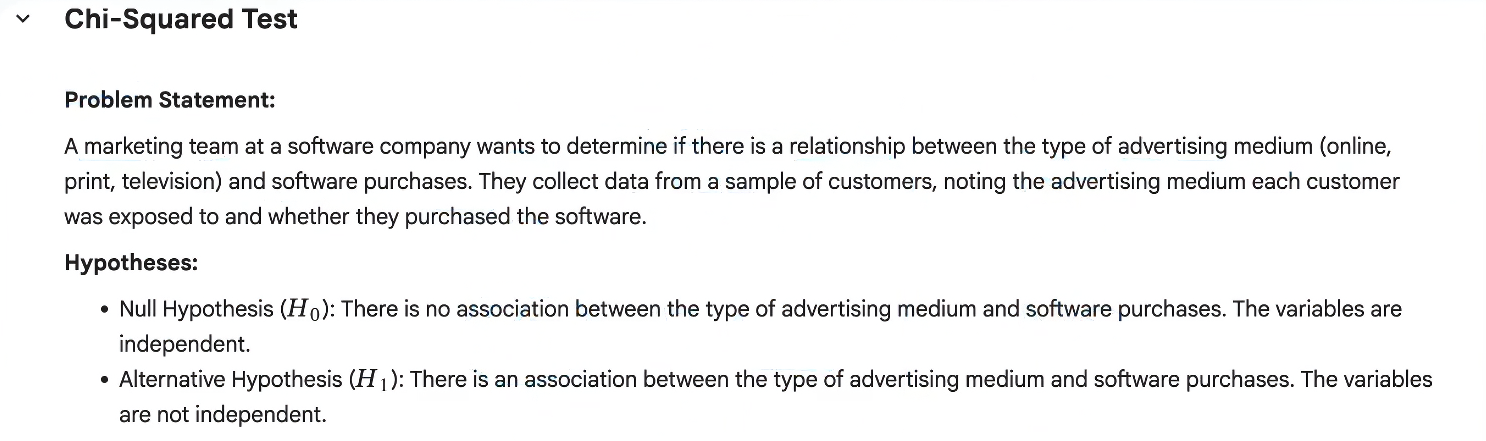

In [11]:
import numpy as np
from scipy.stats import chi2_contingency

# rows = advertising medium (online, print, tv), columns = purchase (yes, no)
data = np.array([[30, 10],
                  [20, 20],
                  [50, 30]])

chi2_stat, p_value, dof, expected = chi2_contingency(data)
print("chi2 stat:", chi2_stat, "p value:", p_value)

if p_value < 0.05:
    print("enough evidence to drop null hypothesis - medium and purchase are related")
else:
    print("not enough evidence to drop null")


chi2 stat: 5.333333333333334 p value: 0.0694834512228015
not enough evidence to drop null
